# Phase 6: Modelling and Hyperparameter Optimization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer

# Configure Plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load the Fully Engineered ML Dataset

In [2]:
processed_dir = Path("../data/processed")
features_path = processed_dir / "final_ml_features.parquet"

df = pd.read_parquet(features_path)

# Drop any NaN rows generated from the lagging/rolling logic (the first 168 hours will be NaN due to the t-168 weekly lag)
df = df.dropna()

print(f"Dataset shape after dropping Nulls: {df.shape}")
df.head(3)

Dataset shape after dropping Nulls: (10009, 36)


,total_demand,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_6,rolling_std_6,rolling_max_6,...,hour,day_of_week,is_weekend,day_of_month,month,quarter,hour_sin,hour_cos,is_holiday,holiday_name
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,1079,2219.0,3740.0,5834.0,1042.0,1051.0,6610.0,5106.500000,1808.302381,7272.0,...,0,2,0,8,1,1,0.000000,1.000000,0,None
2025-01-08 01:00:00,382,1079.0,2219.0,3740.0,423.0,437.0,7481.0,4074.333333,2073.110963,5834.0,...,1,2,0,8,1,1,0.258819,0.965926,0,None
2025-01-08 02:00:00,200,382.0,1079.0,2219.0,242.0,231.0,6126.0,3173.666667,2337.745296,5834.0,...,2,2,0,8,1,1,0.500000,0.866025,0,None


## 2. Train / Test Split

In [4]:
# Sort the dataset chronologically just in case
df.sort_index(inplace=True)

# Determine the index cutoff (80% for train and CV, 20% for test)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# The target variable is 'total_demand'. However, 'holiday_name' is categorical text. We will drop text columns.
DROP_COLS = ['total_demand']
FEATURE_COLS = [col for col in train_df.columns if col not in DROP_COLS]

X_train = train_df[FEATURE_COLS]
y_train = train_df['total_demand']

X_test = test_df[FEATURE_COLS]
y_test = test_df['total_demand']

X_train.to_parquet("../data/processed/X_train.parquet")
X_test.to_parquet("../data/processed/X_test.parquet")
y_train.to_frame().to_parquet("../data/processed/y_train.parquet")
y_test.to_frame().to_parquet("../data/processed/y_test.parquet")

print(f"Training Set: X={X_train.shape}, y={y_train.shape}")
print(f"Holdout Test Set: X={X_test.shape}, y={y_test.shape}")

Training Set: X=(8007, 35), y=(8007,)
Holdout Test Set: X=(2002, 35), y=(2002,)


## 3. Modeling Pipeline Construction

In [ ]:
tscv = TimeSeriesSplit(n_splits=10)

# Evaluation Metric: MAE (Mean Absolute Error) is less sensitive to extreme anomaly spikes than RMSE.
scorer = make_scorer(mean_absolute_error, greater_is_better=False)

def build_pipeline(model):
    """Utility function to wrap a model in standard preprocessing."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures()),
        ('reg', model)
    ])

## 4. Hyperparameter Optimization: Regularized Models

In [23]:
# 1. Ridge Regression Optimization
ridge_pipe = build_pipeline(Ridge(random_state=42))

ridge_param_grid = {
    'poly__degree': [1, 2, 3],
    'reg__alpha': [0.1, 1.0, 10.0]
}

print("Starting Ridge GridSearch...")
ridge_search = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    cv=tscv,
    scoring=scorer,
    n_jobs=-1,
    verbose=3
)

ridge_search.fit(X_train, y_train)
print(f"Best Ridge Params: {ridge_search.best_params_}")
print(f"Best Ridge CV MAE: {-ridge_search.best_score_:.4f}")

Starting Ridge GridSearch...
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Best Ridge Params: {'poly__degree': 1, 'reg__alpha': 0.1}
Best Ridge CV MAE: 374.9196


In [24]:
# 2. Lasso Regression Optimization
lasso_pipe = build_pipeline(Lasso(random_state=42, max_iter=2000))

# Lasso natively drops weak features to 0
lasso_param_grid = {
    'poly__degree': [1, 2, 3],
    'reg__alpha': [0.01, 0.1, 1.0, 10.00]
}

print("Starting Lasso GridSearch...")
lasso_search = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    cv=tscv,
    scoring=scorer,
    n_jobs=-1,
    verbose=1
)

lasso_search.fit(X_train, y_train)
print(f"Best Lasso Params: {lasso_search.best_params_}")
print(f"Best Lasso CV MAE: {-lasso_search.best_score_:.4f}")

Starting Lasso GridSearch...
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Best Lasso Params: {'poly__degree': 2, 'reg__alpha': 10.0}
Best Lasso CV MAE: 357.5199


In [27]:
# 3. ElasticNet Regression Optimization
elasticnet_pipe = build_pipeline(ElasticNet(random_state=42, max_iter=2000))

elasticnet_param_grid = {
    'poly__degree': [1, 2, 3],
    'reg__alpha': [0.01, 0.025, 0.05, 0.1, 1.0],
    'reg__l1_ratio': [0.2, 0.5, 0.8]
}

print("Starting ElasticNet GridSearch...")
elasticnet_search = GridSearchCV(
    estimator=elasticnet_pipe,
    param_grid=elasticnet_param_grid,
    cv=tscv,
    scoring=scorer,
    n_jobs=-1,
    verbose=1
)

elasticnet_search.fit(X_train, y_train)
print(f"Best ElasticNet Params: {elasticnet_search.best_params_}")
print(f"Best ElasticNet CV MAE: {-elasticnet_search.best_score_:.4f}")

Starting ElasticNet GridSearch...
Fitting 10 folds for each of 45 candidates, totalling 450 fits
Best ElasticNet Params: {'poly__degree': 1, 'reg__alpha': 0.01, 'reg__l1_ratio': 0.8}
Best ElasticNet CV MAE: 380.6922


## 5. Hyperparameter Optimization: SGDRegressor

In [28]:
sgd_pipe = build_pipeline(SGDRegressor(random_state=42))

sgd_param_grid = {
    'poly__degree': [1, 2],
    'reg__penalty': ['l2', 'l1', 'elasticnet'],
    'reg__alpha': [0.001, 0.01],
    'reg__learning_rate': ['invscaling', 'adaptive'],
}

print("Starting SGDRegressor GridSearch...")
sgd_search = GridSearchCV(
    estimator=sgd_pipe,
    param_grid=sgd_param_grid,
    cv=tscv,
    scoring=scorer,
    n_jobs=-1,
    verbose=3
)


sgd_search.fit(X_train, y_train)
print(f"Best SGD Params: {sgd_search.best_params_}")
print(f"Best SGD CV MAE: {-sgd_search.best_score_:.4f}")

Starting SGDRegressor GridSearch...
Fitting 10 folds for each of 24 candidates, totalling 240 fits
Best SGD Params: {'poly__degree': 1, 'reg__alpha': 0.001, 'reg__learning_rate': 'adaptive', 'reg__penalty': 'l1'}
Best SGD CV MAE: 376.2655


## 6. Stability and Parsimony: 1-Std Rule
While standard `GridSearchCV` simply selects the model with the absolute best score, this practice can lead to overfitting by picking overly complex models that only perform marginally better. Below, we implement the **1-Standard Error (1-Std) Rule**.

**Approach:**
1. Identify the 'Absolute Best' model (lowest MAE).
2. Calculate its threshold: $Threshold = MAE_{best} + StdDev(MAE_{best})$.
3. Find all candidate models with a mean score within this threshold.
4. Choose the simplest model (lowest `poly__degree`) among these candidates.

In [29]:
def find_stable_params_optimized(search_obj, title="Model", lambda_std=1.0):
    """
    GridSearchCV sonuçlarını, ortalama hata ve standart sapma dengesini
    (mean_mae + lambda * std_mae) baz alarak optimize eder.
    """
    results = pd.DataFrame(search_obj.cv_results_)

    # Negatif MAE skorlarını pozitif MAE'ye çevir
    results['mean_mae'] = -results['mean_test_score']
    results['std_mae'] = results['std_test_score']

    # --- OPTİMİZASYON KRİTERİ ---
    # Hem düşük hata hem düşük varyans isteyen birleşik skor:
    # Score = Mean_MAE + (lambda * Std_MAE)
    # Burada lambda varyansın ne kadar cezalandırılacağını belirler.
    results['stability_score'] = results['mean_mae'] + (lambda_std * results['std_mae'])

    # En iyi (en düşük) stabilite skoruna sahip indeksi bul
    best_stable_idx = results['stability_score'].idxmin()

    stable_params = results.loc[best_stable_idx, 'params']
    stable_mae = results.loc[best_stable_idx, 'mean_mae']
    stable_std = results.loc[best_stable_idx, 'std_mae']
    stable_score = results.loc[best_stable_idx, 'stability_score']

    # Karşılaştırma için mutlak en düşük MAE (standart seçim)
    abs_best_idx = results['mean_mae'].idxmin()

    print(f"=== {title} (Varyans Optimize Edilmiş Seçim) ===")
    print(f"Mutlak En İyi MAE (Standart): {results.loc[abs_best_idx, 'mean_mae']:.4f}")
    print(f"Seçilen Stabil Parametreler: {stable_params}")
    print(f"Seçilen Model MAE: {stable_mae:.4f} ± {stable_std:.4f}")
    print(f"Stabilite Skoru (MAE + {lambda_std}*Std): {stable_score:.4f}")

    # Görselleştirme: Errorbar Grafiği
    plt.figure(figsize=(14, 7))
    plot_data = results.sort_values(by='stability_score').reset_index()

    plt.errorbar(x=range(len(plot_data)), y=plot_data['mean_mae'], yerr=plot_data['std_mae'],
                 fmt='o', ecolor='lightgray', capsize=4, color='gray', label='Aday Modeller', alpha=0.6)

    # Seçilen stabil modeli işaretle
    stable_plot_idx = plot_data[plot_data['index'] == best_stable_idx].index[0]
    plt.errorbar(x=stable_plot_idx, y=stable_mae, yerr=stable_std,
                 fmt='X', color='green', ecolor='green', capsize=6, markersize=12,
                 label='Seçilen Stabil Model (Min Hata+Varyans)')

    plt.title(f"{title} - Hiperparametre Stabilite Analizi", fontsize=14, fontweight='bold')
    plt.xlabel("Aday Modeller (Stabilite Skoruna Göre Sıralı)", fontsize=12)
    plt.ylabel("Ortalama Mutlak Hata (MAE)", fontsize=12)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

    return stable_params, results

Evaluating SGD Models...
=== SGDRegressor (Varyans Optimize Edilmiş Seçim) ===
Mutlak En İyi MAE (Standart): 376.2655
Seçilen Stabil Parametreler: {'poly__degree': 1, 'reg__alpha': 0.001, 'reg__learning_rate': 'adaptive', 'reg__penalty': 'l1'}
Seçilen Model MAE: 376.2655 ± 48.4516
Stabilite Skoru (MAE + 1.0*Std): 424.7172


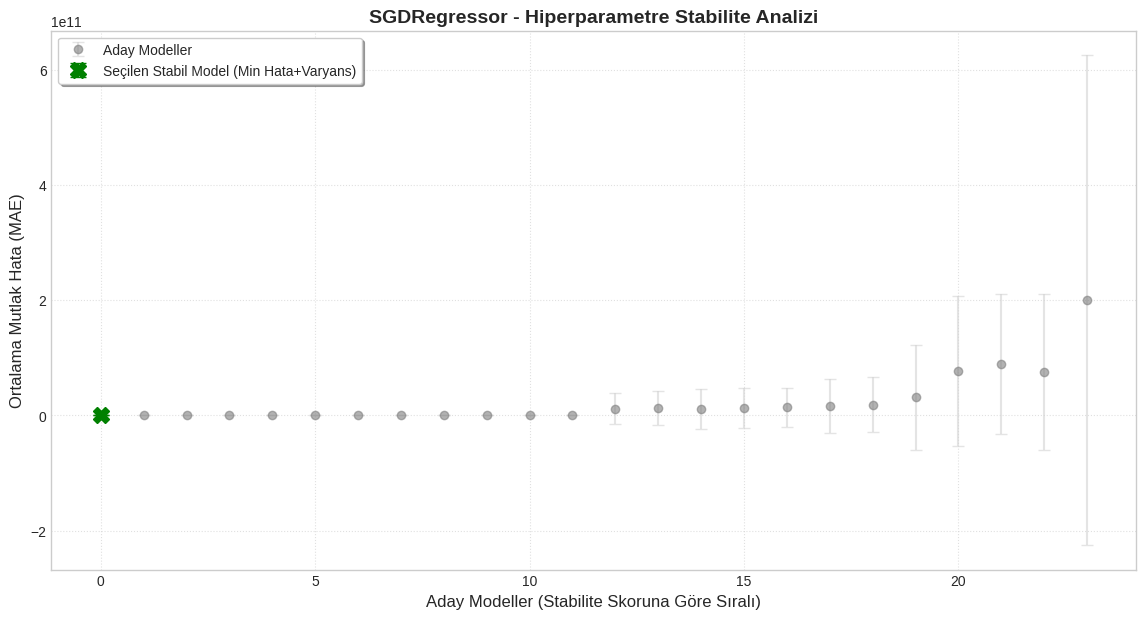

Evaluating Ridge Models...
=== Ridge Regression (Varyans Optimize Edilmiş Seçim) ===
Mutlak En İyi MAE (Standart): 374.9196
Seçilen Stabil Parametreler: {'poly__degree': 1, 'reg__alpha': 1.0}
Seçilen Model MAE: 375.2408 ± 48.5387
Stabilite Skoru (MAE + 1.0*Std): 423.7795


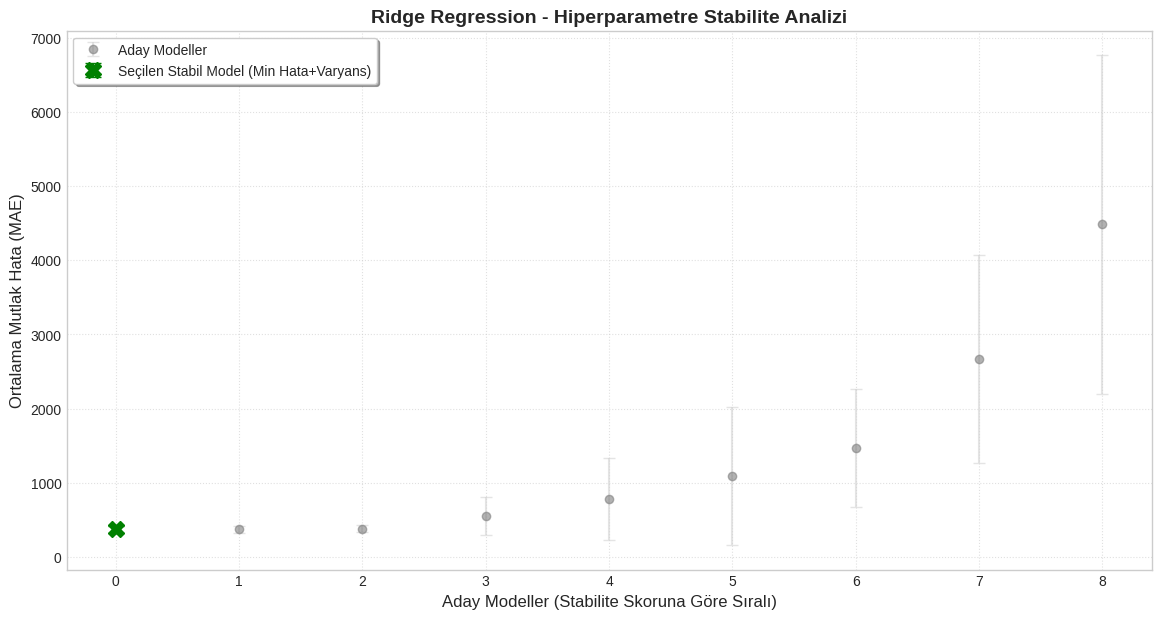

Evaluating Lasso Models...
=== Lasso Regression (Varyans Optimize Edilmiş Seçim) ===
Mutlak En İyi MAE (Standart): 357.5199
Seçilen Stabil Parametreler: {'poly__degree': 2, 'reg__alpha': 10.0}
Seçilen Model MAE: 357.5199 ± 50.6233
Stabilite Skoru (MAE + 1.0*Std): 408.1433


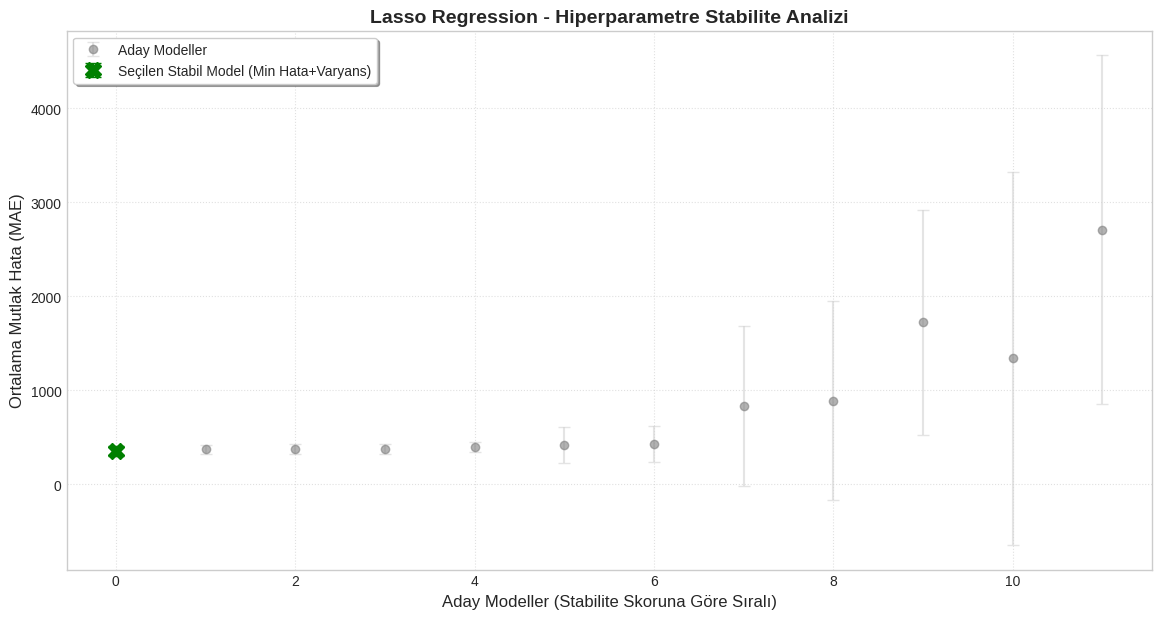

Evaluating ElasticNet Models...
=== ElasticNet Regression (Varyans Optimize Edilmiş Seçim) ===
Mutlak En İyi MAE (Standart): 380.6922
Seçilen Stabil Parametreler: {'poly__degree': 1, 'reg__alpha': 0.01, 'reg__l1_ratio': 0.8}
Seçilen Model MAE: 380.6922 ± 49.9732
Stabilite Skoru (MAE + 1.0*Std): 430.6655


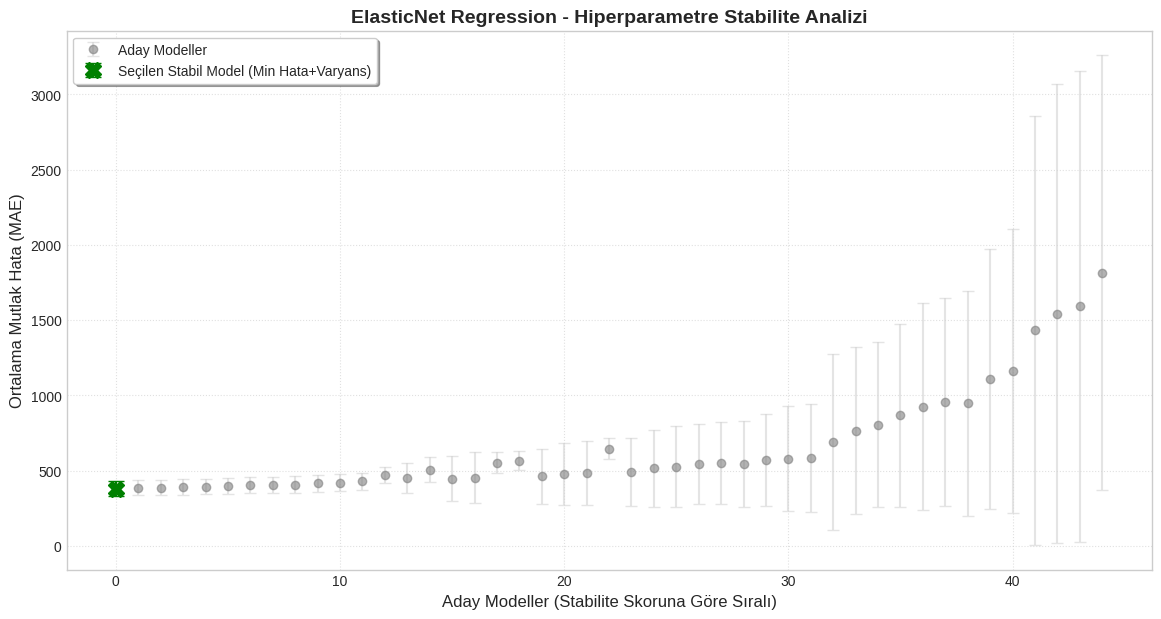

In [30]:
print("Evaluating SGD Models...")
stable_sgd_params, sgd_results = find_stable_params_optimized(sgd_search, title="SGDRegressor")

print("Evaluating Ridge Models...")
stable_ridge_params, ridge_results = find_stable_params_optimized(ridge_search, title="Ridge Regression")

print("Evaluating Lasso Models...")
stable_lasso_params, lasso_results = find_stable_params_optimized(lasso_search, title="Lasso Regression")

print("Evaluating ElasticNet Models...")
stable_elasticnet_params, elasticnet_results = find_stable_params_optimized(elasticnet_search, title="ElasticNet Regression")

## 7. Comparison Chart

In [35]:
def display_top_cv_candidates(results_dict, top_n=3):
    """
    Her model için CV sonuçlarından en iyi N adayı seçer,
    parametreleri, MAE ve Standart Sapma değerleriyle birlikte tablolar.
    """
    all_results = []

    for model_name, df in results_dict.items():
        # Stabilite skoruna göre sırala ve en iyi 'top_n' adayı al
        sorted_df = df.sort_values(by='stability_score').head(top_n).copy()

        for rank, (_, row) in enumerate(sorted_df.iterrows(), 1):
            # Parametre sözlüğünü daha okunabilir bir string formatına çevir
            params_str = ", ".join([f"{k.split('__')[-1]}={v}" for k, v in row['params'].items()])

            all_results.append({
                'Model': model_name,
                'Sıra (Stabilite)': rank,
                'Parametreler': params_str,
                'Ort. Hata (MAE)': row['mean_mae'],
                'Sapma (Std)': row['std_mae'],
                'Skor (MAE+Std)': row['stability_score']
            })

    # Listeyi DataFrame'e çevir
    cv_table_df = pd.DataFrame(all_results)
    return cv_table_df

# Tabloyu oluştur (Her model için en iyi 3 adayı getir)
top_cv_table = display_top_cv_candidates(model_results, top_n=3)

# Sunum kalitesinde renklendirme (Jupyter/Colab için)
# Daha yüksek hatalar ve sapmalar kırmızıya çalar, düşükler mavi/yeşil kalır.
styled_cv_table = top_cv_table.style.set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('font-weight', 'bold'), ('text-align', 'center')]}]
).background_gradient(cmap='Blues', subset=['Ort. Hata (MAE)'])\
 .background_gradient(cmap='Reds', subset=['Sapma (Std)'])\
 .background_gradient(cmap='Greens', subset=['Skor (MAE+Std)'])\
 .format({
     'Ort. Hata (MAE)': "{:.2f}",
     'Sapma (Std)': "{:.2f}",
     'Skor (MAE+Std)': "{:.2f}"
 })\
 .set_properties(**{'text-align': 'center'})

# Tabloyu ekrana bas
display(styled_cv_table)

,Model,Sıra (Stabilite),Parametreler,Ort. Hata (MAE),Sapma (Std),Skor (MAE+Std)
0,SGD Regressor,1,"degree=1, alpha=0.001, learning_rate=adaptive, penalty=l1",376.27,48.45,424.72
1,SGD Regressor,2,"degree=1, alpha=0.01, learning_rate=adaptive, penalty=l1",376.30,48.47,424.77
2,SGD Regressor,3,"degree=1, alpha=0.001, learning_rate=adaptive, penalty=elasticnet",378.38,49.34,427.71
3,Ridge Regression,1,"degree=1, alpha=1.0",375.24,48.54,423.78
4,Ridge Regression,2,"degree=1, alpha=0.1",374.92,49.04,423.96
5,Ridge Regression,3,"degree=1, alpha=10.0",382.01,50.68,432.69
6,Lasso Regression,1,"degree=2, alpha=10.0",357.52,50.62,408.14
7,Lasso Regression,2,"degree=1, alpha=0.1",375.48,49.21,424.69
8,Lasso Regression,3,"degree=1, alpha=1.0",376.38,48.70,425.08
9,ElasticNet Regression,1,"degree=1, alpha=0.01, l1_ratio=0.8",380.69,49.97,430.67


## 8. Saving Stable Models

In [34]:
import joblib
# 1. Setup the models directory
models_dir = Path("/content/models")
models_dir.mkdir(parents=True, exist_ok=True)

# 2. Retrain and Save the Stable Ridge Model
print("Retraining final Ridge model with stable parameters...")
final_ridge_model = build_pipeline(Ridge(random_state=42))
final_ridge_model.set_params(**stable_ridge_params)
final_ridge_model.fit(X_train, y_train)

ridge_path = models_dir / "ridge_stable_model.joblib"
joblib.dump(final_ridge_model, ridge_path)
print(f"Ridge model saved to: {ridge_path}")

# 3. Retrain and Save the Stable Lasso Model
# Note: Using the best_params_ from the completed lasso_search
print("\nRetraining final Lasso model...")
final_lasso_model = build_pipeline(Lasso(random_state=42, max_iter=2000))
final_lasso_model.set_params(**stable_lasso_params)
final_lasso_model.fit(X_train, y_train)

lasso_path = models_dir / "lasso_stable_model.joblib"
joblib.dump(final_lasso_model, lasso_path)
print(f"Lasso model saved to: {lasso_path}")


# 4. Retrain and Save the Stable ElasticNet Model
print("\nRetraining final ElasticNet model with stable parameters...")
final_elasticnet_model = build_pipeline(ElasticNet(random_state=42, max_iter=2000))
final_elasticnet_model.set_params(**stable_elasticnet_params)
final_elasticnet_model.fit(X_train, y_train)

elasticnet_path = models_dir / "elasticnet_stable_model.joblib"
joblib.dump(final_elasticnet_model, elasticnet_path)
print(f"ElasticNet model saved to: {elasticnet_path}")

# 5. Retrain and Save the Stable SGDRegressor Model
final_sgd_model = build_pipeline(SGDRegressor(random_state=42))
final_sgd_model.set_params(**stable_sgd_params)
final_sgd_model.fit(X_train, y_train)

sgd_path = models_dir / "elasticnet_stable_model.joblib"
joblib.dump(final_sgd_model, sgd_path)
print(f"ElasticNet model saved to: {sgd_path}")

# 6. Save metadata (Feature names) for Phase 7
feature_metadata = {
    'features': FEATURE_COLS,
    'target': 'total_demand'
}
joblib.dump(feature_metadata, models_dir / "model_metadata.joblib")
print("\nModel metadata saved successfully.")

Retraining final Ridge model with stable parameters...
Ridge model saved to: /content/models/ridge_stable_model.joblib

Retraining final Lasso model...
Lasso model saved to: /content/models/lasso_stable_model.joblib

Retraining final ElasticNet model with stable parameters...
ElasticNet model saved to: /content/models/elasticnet_stable_model.joblib
ElasticNet model saved to: /content/models/elasticnet_stable_model.joblib

Model metadata saved successfully.
